In [9]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

In [10]:
def load_data(file_path):
    return pd.read_csv(file_path)

df = load_data(file_path="../data/raw/telco.csv")
print(df.head(2))

  Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   

   Number of Dependents        Country       State  ...  \
0                     0  United States  California  ...   
1                     1  United States  California  ...   

  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
0                       20                          0.0          59.65   
1                        0                        390.8        1024.10   

   Satisfaction Score  Customer Status Churn Label Churn Score  CLTV  \
0                   3          Churned         Yes          91  5433   
1                   3          Churned         Yes          69  5302   

   Churn Category                  Churn Reason  
0      Competitor  Competitor offered more data  
1      Competitor  Competitor made better offer  

[2 rows x 5

In [11]:
# Create a Backup Copy

df_clean = df.copy()
print(df_clean.head(2))

  Customer ID  Gender  Age Under 30 Senior Citizen Married Dependents  \
0  8779-QRDMV    Male   78       No            Yes      No         No   
1  7495-OOKFY  Female   74       No            Yes     Yes        Yes   

   Number of Dependents        Country       State  ...  \
0                     0  United States  California  ...   
1                     1  United States  California  ...   

  Total Extra Data Charges  Total Long Distance Charges  Total Revenue  \
0                       20                          0.0          59.65   
1                        0                        390.8        1024.10   

   Satisfaction Score  Customer Status Churn Label Churn Score  CLTV  \
0                   3          Churned         Yes          91  5433   
1                   3          Churned         Yes          69  5302   

   Churn Category                  Churn Reason  
0      Competitor  Competitor offered more data  
1      Competitor  Competitor made better offer  

[2 rows x 5

In [12]:
# Check Missing Values

print(df_clean.isnull().sum())

# percentage
round((df_clean.isnull().sum() / len(df_clean)) * 100,2)

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

Customer ID                           0.00
Gender                                0.00
Age                                   0.00
Under 30                              0.00
Senior Citizen                        0.00
Married                               0.00
Dependents                            0.00
Number of Dependents                  0.00
Country                               0.00
State                                 0.00
City                                  0.00
Zip Code                              0.00
Latitude                              0.00
Longitude                             0.00
Population                            0.00
Quarter                               0.00
Referred a Friend                     0.00
Number of Referrals                   0.00
Tenure in Months                      0.00
Offer                                55.05
Phone Service                         0.00
Avg Monthly Long Distance Charges     0.00
Multiple Lines                        0.00
Internet Se

In [13]:
# Handle Missing Values

# Offer
#Customers with no recorded offer likely did not receive one.

df_clean["Offer"] = df_clean["Offer"].fillna("No Offer")
print(df_clean["Offer"])

0       No Offer
1        Offer E
2        Offer D
3        Offer C
4        Offer C
          ...   
7038    No Offer
7039     Offer C
7040    No Offer
7041    No Offer
7042    No Offer
Name: Offer, Length: 7043, dtype: object


In [14]:
# Internet Type
# Customers without internet service do not have an internet type.

df_clean["Internet Type"] = df_clean["Internet Type"].fillna("No Internet")
print(df_clean["Internet Type"])

0               DSL
1       Fiber Optic
2       Fiber Optic
3       Fiber Optic
4       Fiber Optic
           ...     
7038    No Internet
7039          Cable
7040    Fiber Optic
7041            DSL
7042    Fiber Optic
Name: Internet Type, Length: 7043, dtype: object


In [15]:
# Churn Reason
# Applicable only to customers who churned.

df_clean["Churn Reason"] = df_clean["Churn Reason"].fillna("Not Applicable")
print(df_clean["Churn Reason"])

0       Competitor offered more data
1       Competitor made better offer
2       Competitor made better offer
3          Limited range of services
4                 Extra data charges
                    ...             
7038                  Not Applicable
7039                  Not Applicable
7040                  Not Applicable
7041                  Not Applicable
7042                  Not Applicable
Name: Churn Reason, Length: 7043, dtype: object


In [16]:
# Verify Missing Values

print(df_clean.isnull().sum())

# percentage
round((df_clean.isnull().sum() / len(df_clean)) * 100,2)

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                   0
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

Customer ID                           0.00
Gender                                0.00
Age                                   0.00
Under 30                              0.00
Senior Citizen                        0.00
Married                               0.00
Dependents                            0.00
Number of Dependents                  0.00
Country                               0.00
State                                 0.00
City                                  0.00
Zip Code                              0.00
Latitude                              0.00
Longitude                             0.00
Population                            0.00
Quarter                               0.00
Referred a Friend                     0.00
Number of Referrals                   0.00
Tenure in Months                      0.00
Offer                                 0.00
Phone Service                         0.00
Avg Monthly Long Distance Charges     0.00
Multiple Lines                        0.00
Internet Se

In [17]:
# Check Duplicate Records

print(df_clean.duplicated().sum())

0


In [18]:
# Verify Data Types

print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [19]:
# Remove Extra Spaces from text columns.

object_cols = df_clean.select_dtypes(include="object").columns

for col in object_cols:
    df_clean[col] = df_clean[col].str.strip()

In [20]:
# Check for Inconsistent Categories

for col in object_cols:
    print(f"\n {col}")
    print(df_clean[col].value_counts())


 Customer ID
Customer ID
8779-QRDMV    1
7495-OOKFY    1
1658-BYGOY    1
4598-XLKNJ    1
4846-WHAFZ    1
             ..
2569-WGERO    1
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

 Gender
Gender
Male      3555
Female    3488
Name: count, dtype: int64

 Under 30
Under 30
No     5642
Yes    1401
Name: count, dtype: int64

 Senior Citizen
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

 Married
Married
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     5416
Yes    1627
Name: count, dtype: int64

 Country
Country
United States    7043
Name: count, dtype: int64

 State
State
California    7043
Name: count, dtype: int64

 City
City
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Eldridge              2
South Lake Tahoe      2
Johannesburg          2
Jacumba               2
Holtville      

In [21]:
# Validate Numerical Columns

print(df_clean.describe())

               Age  Number of Dependents      Zip Code     Latitude  \
count  7043.000000           7043.000000   7043.000000  7043.000000   
mean     46.509726              0.468692  93486.070567    36.197455   
std      16.750352              0.962802   1856.767505     2.468929   
min      19.000000              0.000000  90001.000000    32.555828   
25%      32.000000              0.000000  92101.000000    33.990646   
50%      46.000000              0.000000  93518.000000    36.205465   
75%      60.000000              0.000000  95329.000000    38.161321   
max      80.000000              9.000000  96150.000000    41.962127   

         Longitude     Population  Number of Referrals  Tenure in Months  \
count  7043.000000    7043.000000          7043.000000       7043.000000   
mean   -119.756684   22139.603294             1.951867         32.386767   
std       2.154425   21152.392837             3.001199         24.542061   
min    -124.301372      11.000000             0.000000  

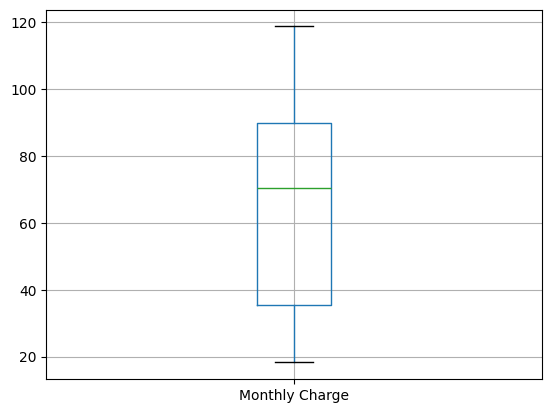

In [22]:
# Detect Outliers

df_clean.boxplot(column="Monthly Charge")
plt.show()

In [23]:
# Standardize column names

df_clean.columns = (df_clean.columns.str.strip().str.lower().str.replace(" ", "_"))
print(df_clean.columns)

Index(['customer_id', 'gender', 'age', 'under_30', 'senior_citizen', 'married',
       'dependents', 'number_of_dependents', 'country', 'state', 'city',
       'zip_code', 'latitude', 'longitude', 'population', 'quarter',
       'referred_a_friend', 'number_of_referrals', 'tenure_in_months', 'offer',
       'phone_service', 'avg_monthly_long_distance_charges', 'multiple_lines',
       'internet_service', 'internet_type', 'avg_monthly_gb_download',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_tech_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'satisfaction_score', 'customer_status', 'churn_label',
       'churn_score', 'cltv', 'churn_category', 'churn_reason'],
      dtype='object')


In [24]:
# Save the Clean Dataset

df_clean.to_csv("../data/processed/telco_clean.csv")